In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
RAW_DIR = "../data/wisdm-dataset/raw"
SUBJECTS = range(1600, 1651)  # 51 subjects

SENSORS = [("phone", "accel"), ("phone", "gyro"), ("watch", "accel"), ("watch", "gyro")]

ACTIVITIES = {
    "A": "Walking",
    "B": "Jogging",
    "C": "Stairs",
    "D": "Sitting",
    "E": "Standing",
    "F": "Typing",
    "G": "Brushing Teeth",
    "H": "Eating Soup",
    "I": "Eating Chips",
    "J": "Eating Pasta",
    "K": "Drinking from Cup",
    "L": "Eating Sandwich",
    "M": "Kicking (Soccer Ball)",
    "O": "Playing Catch w/Tennis Ball",
    "P": "Dribbling (Basketball)",
    "Q": "Writing",
    "R": "Clapping",
    "S": "Folding Clothes",
}

In [10]:
def get_sensor_data(filepath):
    df = pd.read_csv(
        filepath,
        header=None,
        names=["subject_id", "activity", "timeStamp", "x", "y", "z"],
    )

    df.iloc[:, -1] = df.iloc[:, -1].str.rstrip(";")

    df = df.astype({"z": float})

    df["timeStamp"] = pd.to_datetime(df["timeStamp"], unit="ns")
    df.drop(columns="subject_id", inplace=True)

    return df

In [11]:
def get_subject_data(subject_id, log):

    dfs: list[pd.DataFrame] = []

    for device, sensor in SENSORS:

        df = get_sensor_data(
            f"{RAW_DIR}/{device}/{sensor}/data_{subject_id}_{sensor}_{device}.txt"
        )

        df["device"] = device

        df = df.rename(
            columns={
                "x": f"x_{sensor}",
                "y": f"y_{sensor}",
                "z": f"z_{sensor}",
            }
        )

        dfs.append(df)

    for df in dfs:
        df.sort_values(by="timeStamp", inplace=True)

    merged_phone = pd.merge_asof(
        dfs[0] if dfs[0].shape[0] < dfs[1].shape[0] else dfs[1],
        dfs[0] if dfs[0].shape[0] >= dfs[1].shape[0] else dfs[1],
        on="timeStamp",
        by=["activity", "device"],
        direction="nearest",
        tolerance=pd.Timedelta("100ms"),
    )

    if log:
        print(f"{merged_phone.shape[0]} rows of phone data")

    # return merged_phone

    merged_watch = pd.merge_asof(
        dfs[2] if dfs[2].shape[0] < dfs[3].shape[0] else dfs[3],
        dfs[2] if dfs[2].shape[0] >= dfs[3].shape[0] else dfs[3],
        on="timeStamp",
        by=["activity", "device"],
        direction="nearest",
        tolerance=pd.Timedelta("100ms"),
    )

    if log:
        print(f"{merged_watch.shape[0]} rows of phone data")

    merged = pd.concat([merged_phone, merged_watch])

    merged = merged.iloc[:, [5, 0, 1, 2, 3, 4, 6, 7, 8]]

    merged["activity"] = merged["activity"].astype("category")
    merged["device"] = merged["device"].astype("category")

    return merged.sort_values(by=["device", "activity", "timeStamp"])

In [12]:
df = get_subject_data(1600, True)

df.info()

64247 rows of phone data
65435 rows of phone data
<class 'pandas.DataFrame'>
Index: 129682 entries, 39263 to 18590
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     129682 non-null  category      
 1   activity   129682 non-null  category      
 2   timeStamp  129682 non-null  datetime64[ns]
 3   x_gyro     129682 non-null  float64       
 4   y_gyro     129682 non-null  float64       
 5   z_gyro     129682 non-null  float64       
 6   x_accel    129682 non-null  float64       
 7   y_accel    129682 non-null  float64       
 8   z_accel    129682 non-null  float64       
dtypes: category(2), datetime64[ns](1), float64(6)
memory usage: 8.2 MB


In [13]:
def load_all_data():

    merged = pd.DataFrame()

    for subject_id in SUBJECTS:

        print(f"loading {subject_id} data...")

        if subject_id == SUBJECTS.start:
            merged = get_subject_data(subject_id, False)
            merged["subject_id"] = np.ones(merged.shape[0], dtype=int) * subject_id
            continue

        other = get_subject_data(subject_id, False)
        other["subject_id"] = np.ones(other.shape[0], dtype=int) * subject_id
        merged = pd.concat([merged, other])

    merged["subject_id"] = merged["subject_id"].astype("category")
    merged["activity"] = merged["activity"].astype("category")

    merged = merged.reindex(
        columns=[
            "subject_id",
            "device",
            "activity",
            "timeStamp",
            "x_accel",
            "y_accel",
            "z_accel",
            "x_gyro",
            "y_gyro",
            "z_gyro",
        ]
    )

    return merged

In [14]:
df = load_all_data()

loading 1600 data...
loading 1601 data...
loading 1602 data...
loading 1603 data...
loading 1604 data...
loading 1605 data...
loading 1606 data...
loading 1607 data...
loading 1608 data...
loading 1609 data...
loading 1610 data...
loading 1611 data...
loading 1612 data...
loading 1613 data...
loading 1614 data...
loading 1615 data...
loading 1616 data...
loading 1617 data...
loading 1618 data...
loading 1619 data...
loading 1620 data...
loading 1621 data...
loading 1622 data...
loading 1623 data...
loading 1624 data...
loading 1625 data...
loading 1626 data...
loading 1627 data...
loading 1628 data...
loading 1629 data...
loading 1630 data...
loading 1631 data...
loading 1632 data...
loading 1633 data...
loading 1634 data...
loading 1635 data...
loading 1636 data...
loading 1637 data...
loading 1638 data...
loading 1639 data...
loading 1640 data...
loading 1641 data...
loading 1642 data...
loading 1643 data...
loading 1644 data...
loading 1645 data...
loading 1646 data...
loading 1647 

In [15]:
df = df.dropna()

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 7044509 entries, 39263 to 17993
Data columns (total 10 columns):
 #   Column      Dtype         
---  ------      -----         
 0   subject_id  category      
 1   device      category      
 2   activity    category      
 3   timeStamp   datetime64[ns]
 4   x_accel     float64       
 5   y_accel     float64       
 6   z_accel     float64       
 7   x_gyro      float64       
 8   y_gyro      float64       
 9   z_gyro      float64       
dtypes: category(3), datetime64[ns](1), float64(6)
memory usage: 450.1 MB


In [17]:
df[(df["activity"] == "A") & (df["subject_id"] == 1600)].__len__() / df.__len__() * 100

0.10180979256325742

<Axes: >

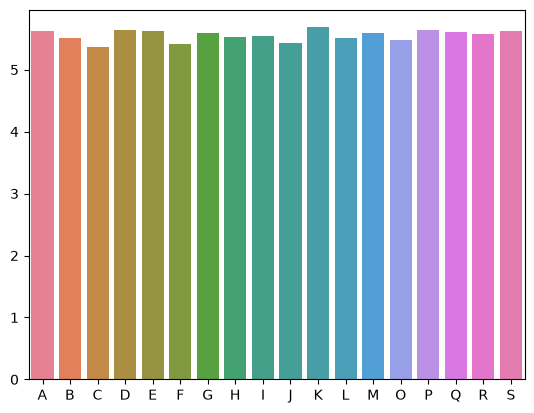

In [18]:
activity_percent = {}

for activity in ACTIVITIES.keys():
    activity_percent[activity] = (
        df[df["activity"] == activity].__len__() / df.__len__() * 100
    )

activity_percent = pd.DataFrame([activity_percent])

sns.barplot(activity_percent)

In [19]:
df

,subject_id,device,activity,timeStamp,x_accel,y_accel,z_accel,x_gyro,y_gyro,z_gyro
39263,1600,phone,A,1970-01-03 22:03:27.918580802,-4.332779,13.361191,-0.718872,-0.853210,0.297226,0.890182
39264,1600,phone,A,1970-01-03 22:03:27.968934806,-0.319443,13.318359,-0.232025,-0.875137,0.015472,0.162231
39265,1600,phone,A,1970-01-03 22:03:28.019288809,1.566452,9.515274,-0.017776,-0.720169,0.388489,-0.284012
39266,1600,phone,A,1970-01-03 22:03:28.069642813,-0.323746,5.262665,0.322342,-0.571640,1.227402,-0.241669
39267,1600,phone,A,1970-01-03 22:03:28.119996817,-1.811676,3.710510,1.373932,-0.380493,1.202835,-0.213135
...,...,...,...,...,...,...,...,...,...,...
17989,1650,watch,S,1970-01-29 01:56:24.371437252,2.137723,-7.211485,8.065467,-2.856065,2.057101,0.853933
17990,1650,watch,S,1970-01-29 01:56:24.421424592,1.486500,-13.302334,5.355231,-2.911458,1.817417,1.281104
17991,1650,watch,S,1970-01-29 01:56:24.471411932,4.017171,-13.146711,5.118205,-3.015854,1.550036,2.057682
17992,1650,watch,S,1970-01-29 01:56:24.521399272,4.412214,-15.318253,3.370437,-3.218254,1.595842,3.018550


C:\Users\netinova\AppData\Local\Temp\ipykernel_12572\2444229645.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


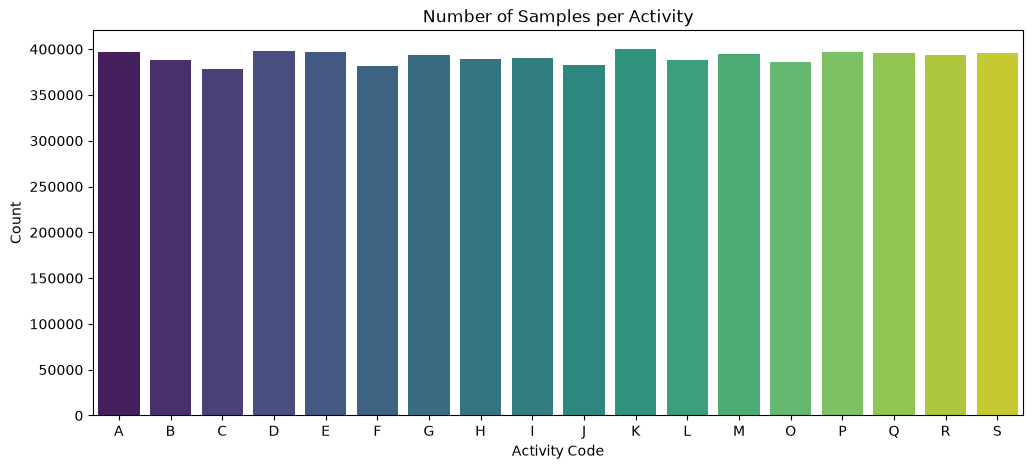

In [ ]:
activity_counts = df["activity"].value_counts().sort_index()
plt.figure(figsize=(12, 5))
sns.barplot(
    x=activity_counts.index,
    y=activity_counts.values,
    palette="viridis",
)
plt.title("Number of Samples per Activity")
plt.xlabel("Activity Code")
plt.ylabel("Count")
plt.show()

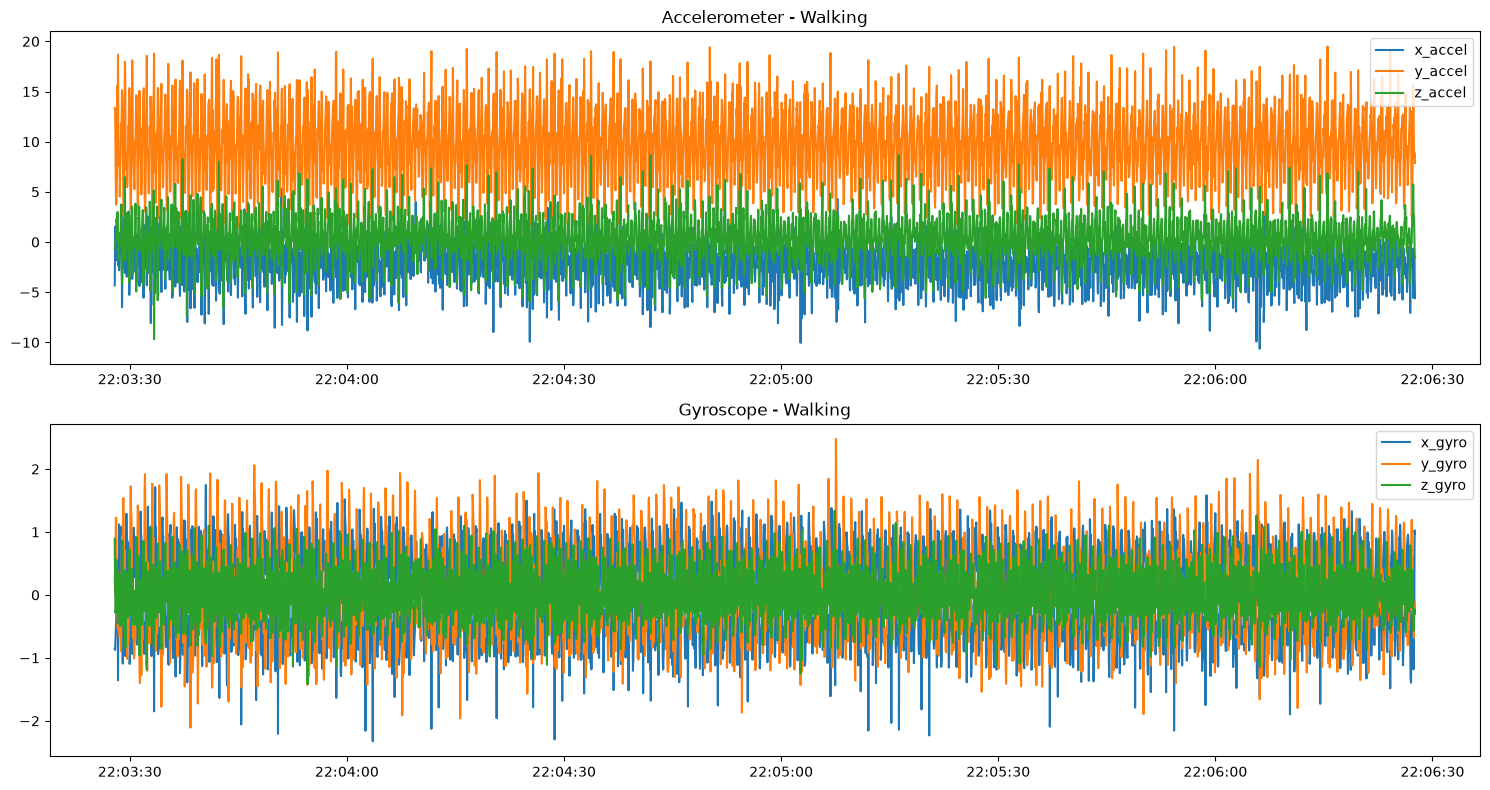

In [ ]:
# Example: subject 1600, activity 'A' (Walking), phone
sample = df[
    (df["subject_id"] == 1600) & (df["activity"] == "A") & (df["device"] == "phone")
]
sample = sample.sort_values("timeStamp")

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(sample["timeStamp"], sample["x_accel"], label="x_accel")
axes[0].plot(sample["timeStamp"], sample["y_accel"], label="y_accel")
axes[0].plot(sample["timeStamp"], sample["z_accel"], label="z_accel")
axes[0].set_title("Accelerometer - Walking")
axes[0].legend()

axes[1].plot(sample["timeStamp"], sample["x_gyro"], label="x_gyro")
axes[1].plot(sample["timeStamp"], sample["y_gyro"], label="y_gyro")
axes[1].plot(sample["timeStamp"], sample["z_gyro"], label="z_gyro")
axes[1].set_title("Gyroscope - Walking")
axes[1].legend()
plt.tight_layout()
plt.show()

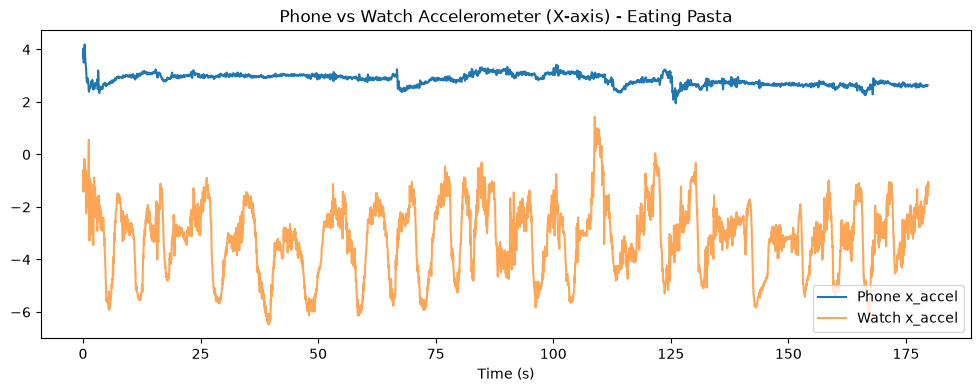

In [ ]:
# Choose one subject and activity
subj, act = 1600, "J"
phone = df[
    (df["subject_id"] == subj) & (df["activity"] == act) & (df["device"] == "phone")
]
watch = df[
    (df["subject_id"] == subj) & (df["activity"] == act) & (df["device"] == "watch")
]

# Align by relative time
phone = phone.sort_values("timeStamp")
watch = watch.sort_values("timeStamp")


phone["rel_time"] = (phone["timeStamp"] - phone["timeStamp"].iloc[0]).dt.total_seconds()
watch["rel_time"] = (watch["timeStamp"] - watch["timeStamp"].iloc[0]).dt.total_seconds()

plt.figure(figsize=(12, 4))
plt.plot(phone["rel_time"], phone["x_accel"], label="Phone x_accel")
plt.plot(watch["rel_time"], watch["x_accel"], label="Watch x_accel", alpha=0.7)
plt.title(f"Phone vs Watch Accelerometer (X-axis) - {ACTIVITIES[act]}")
plt.xlabel("Time (s)")
plt.legend()
plt.show()

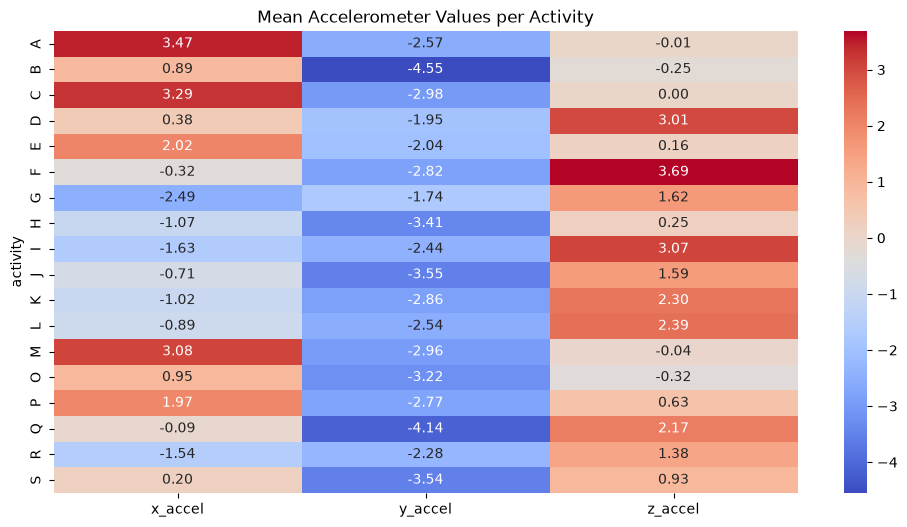

In [ ]:
agg_stats = df.groupby("activity")[
    ["x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"]
].agg(["mean", "std"])


means = agg_stats.xs("mean", axis=1, level=1)
stds = agg_stats.xs("std", axis=1, level=1)

plt.figure(figsize=(12, 6))
sns.heatmap(
    means[["x_accel", "y_accel", "z_accel"]], annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Mean Accelerometer Values per Activity")
plt.show()